# Balancing the Dataset

The GTSRB is notoriously an unbalanced dataset. In this notebook we will evaluate the performance of the original dataset vs a balanced dataset. 

Note that balancing also involves adding data to the dataset, hence this can be considered as a data augmentation process.

In [27]:
import torch
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

# Auxiliary functions from previous classes

In [28]:
def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss
            correct += (predicted == targets).sum()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss.cpu().detach().numpy())
        history['loss'].append(epoch_loss.cpu().detach().numpy())
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.fc1 = torch.nn.Linear(1200, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x) # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x) # -> (bs, 32, 14, 14)
        
        x = self.conv3(x) # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x) # -> (bs, 48, 5, 5)
        
        x = torch.flatten(x,1) # -> (bs, 48 * 5 * 5 = 1200)
        x = self.fc1(x)        # -> (bs, num_classes)

        return(x)



class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    


def build_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_confusion_matrix(ground_truth, preds, len(test_set.classes))      


In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

PATH_TRAINING_SET = 'd:/vcpi/gtsrb/train'
PATH_TEST_SET = 'd:/vcpi/gtsrb/test_A'
PATH_VAL_SET = 'd:/vcpi/gtsrb/val'

BATCH_SIZE = 32

EPOCHS = 50

MODE = 'train'

cuda:0


In [30]:
transform = transforms.Compose(
    [transforms.Resize((32,32)), transforms.ToTensor()]) 

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)


Counter({2: 1770, 1: 1740, 4: 1590, 5: 1500, 6: 1170, 3: 1140, 7: 1110, 0: 180})


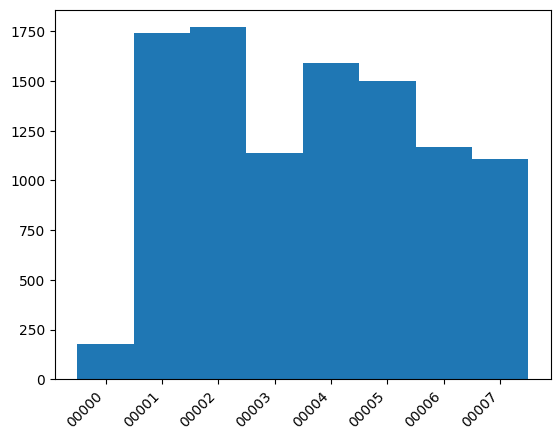

In [31]:
target_list = []
for images, targets in train_loader:
    target_list.extend(targets)

vcpi_util.show_histogram(target_list, train_set.classes)

# Train and evaluate for 5 runs

## Train

In [32]:
RUNS = 5

if MODE == 'train':
    loss_fn = torch.nn.CrossEntropyLoss()

    for i in range(RUNS):
        model_Conv = Conv(len(train_set.classes))
        model_Conv.to(device)

        early_stop = Early_Stopping(9)
        optimizer = torch.optim.Adam(model_Conv.parameters())
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    
        history_I = train_III(model_Conv, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'gtsrb_{i}')

Epoch: 000; Loss: 0.014591; Accuracy: 84.5196; Val Loss: 0.007484; Val Acc: 92.7132; Elapsed time: 6.4773
Epoch: 001; Loss: 0.001018; Accuracy: 99.4314; Val Loss: 0.003455; Val Acc: 96.4729; Elapsed time: 6.5989
Epoch: 002; Loss: 0.000342; Accuracy: 99.8235; Val Loss: 0.005624; Val Acc: 93.7597; Elapsed time: 6.5316
Epoch: 003; Loss: 0.000140; Accuracy: 99.9706; Val Loss: 0.003224; Val Acc: 96.5891; Elapsed time: 6.5175
Epoch: 004; Loss: 0.000344; Accuracy: 99.7451; Val Loss: 0.004583; Val Acc: 95.3488; Elapsed time: 6.4821
Epoch: 005; Loss: 0.000524; Accuracy: 99.6274; Val Loss: 0.004636; Val Acc: 95.1550; Elapsed time: 6.4551
Epoch: 006; Loss: 0.000282; Accuracy: 99.7451; Val Loss: 0.004233; Val Acc: 95.3488; Elapsed time: 6.4372
Epoch: 007; Loss: 0.000214; Accuracy: 99.8137; Val Loss: 0.003149; Val Acc: 96.8992; Elapsed time: 6.4436
Epoch: 008; Loss: 0.000013; Accuracy: 100.0000; Val Loss: 0.002291; Val Acc: 97.3643; Elapsed time: 6.5365
Epoch: 009; Loss: 0.000005; Accuracy: 100.000

## Evaluate

In [33]:
res = 0

for i in range(RUNS):

    reload = torch.load(f'gtsrb_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    print(reload['epoch'], eval)
    res += eval

res /= RUNS    
print(res)

27 0.9877697825431824
19 0.9856114983558655
20 0.9844124913215637
15 0.9762589931488037
17 0.9856114983558655
0.9839328527450562


# Balanced dataset

Create the data loader and show the histogram

In [34]:
PATH_BALANCED_TRAINING_SET = 'd:/vcpi/gtsrb/train_balanced_2000'

balanced_train_set = torchvision.datasets.ImageFolder(root=PATH_BALANCED_TRAINING_SET, transform = transform)
balanced_train_loader = torch.utils.data.DataLoader(balanced_train_set, batch_size = BATCH_SIZE, shuffle=True)

Counter({7: 2000, 1: 2000, 3: 2000, 6: 2000, 0: 2000, 2: 2000, 5: 2000, 4: 2000})


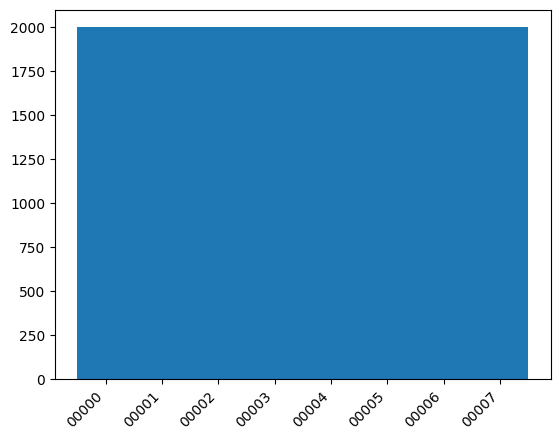

In [35]:
target_list = []
for images, targets in balanced_train_loader:
    target_list.extend(targets)

vcpi_util.show_histogram(target_list, train_set.classes)

## Train runs

In [36]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv = Conv(len(train_set.classes))
    model_Conv.to(device)

    early_stop = Early_Stopping(9)
    optimizer = torch.optim.Adam(model_Conv.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv, balanced_train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'gtsrb_balanced_{i}')


Epoch: 000; Loss: 0.013202; Accuracy: 86.3375; Val Loss: 0.007977; Val Acc: 91.6667; Elapsed time: 9.1247
Epoch: 001; Loss: 0.001914; Accuracy: 98.3625; Val Loss: 0.005071; Val Acc: 94.8450; Elapsed time: 9.1424
Epoch: 002; Loss: 0.000810; Accuracy: 99.2938; Val Loss: 0.004810; Val Acc: 95.2326; Elapsed time: 9.0427
Epoch: 003; Loss: 0.000615; Accuracy: 99.4563; Val Loss: 0.006245; Val Acc: 93.4496; Elapsed time: 9.1381
Epoch: 004; Loss: 0.000685; Accuracy: 99.3563; Val Loss: 0.005515; Val Acc: 94.0698; Elapsed time: 9.1353
Epoch: 005; Loss: 0.000532; Accuracy: 99.5063; Val Loss: 0.006093; Val Acc: 92.7907; Elapsed time: 9.0943
==> Learning rate updated:  0.001  ->  0.0001
Epoch: 006; Loss: 0.000273; Accuracy: 99.7500; Val Loss: 0.005291; Val Acc: 93.0620; Elapsed time: 9.0180
Epoch: 007; Loss: 0.000177; Accuracy: 99.8375; Val Loss: 0.001954; Val Acc: 97.9070; Elapsed time: 9.0789
Epoch: 008; Loss: 0.000051; Accuracy: 99.9875; Val Loss: 0.001858; Val Acc: 98.1008; Elapsed time: 9.1956


## Evaluate

In [37]:
res = 0

for i in range(RUNS):

    reload = torch.load(f'gtsrb_balanced_{i}_best.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    print(reload['epoch'], eval)
    res += eval

res /= RUNS    
print(res)

25 0.9882494211196899
24 0.9892086386680603
37 0.9892086386680603
24 0.9894484281539917
20 0.9877697825431824
0.9887769818305969


# Show stats 

## History

The history for the last run for each train set


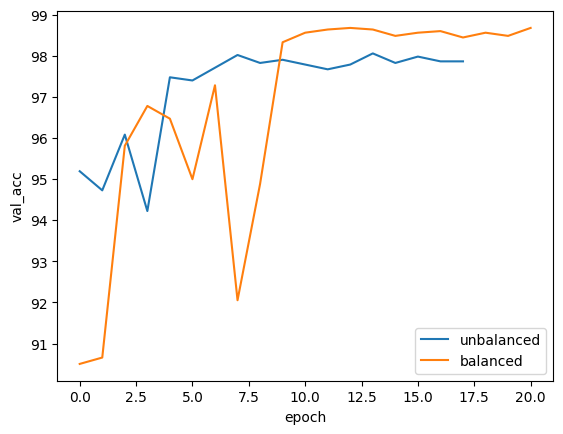

In [38]:
vcpi_util.show_histories([history_I, history_II], ['unbalanced', 'balanced'], 'val_acc')

In [40]:
reload = torch.load(f'gtsrb_{RUNS-1}_best.pt')
print(reload['epoch'])
model_Conv_I = Conv(len(train_set.classes))
model_Conv_I.to(device)
model_Conv_I.load_state_dict(reload['model'])
evaluate(model_Conv_I, test_loader)

17


0.9856114983558655

In [41]:
reload = torch.load(f'gtsrb_balanced_{RUNS-1}_best.pt')
print(reload['epoch'])
model_Conv_II = Conv(len(train_set.classes))
model_Conv_II.to(device)
model_Conv_II.load_state_dict(reload['model'])
evaluate(model_Conv_II, test_loader)

20


0.9877697825431824

## Confusion Matrices

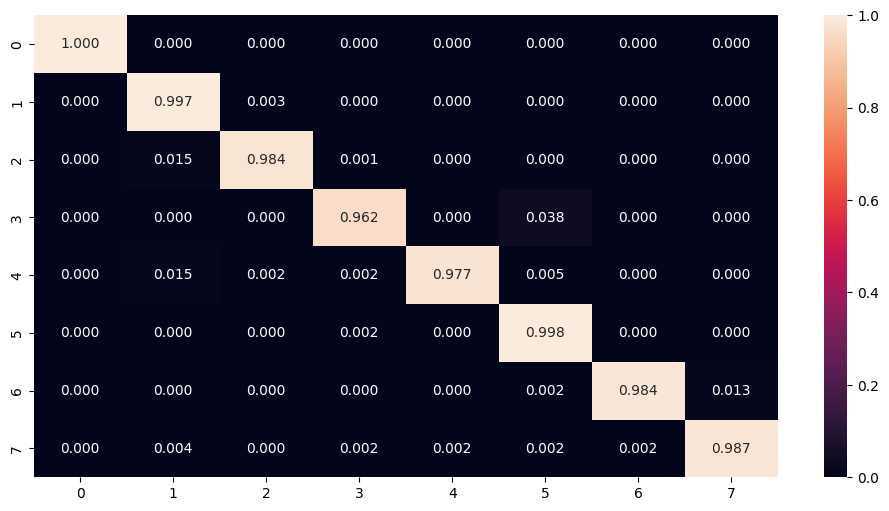

In [42]:
build_confusion_matrix(model_Conv_I, test_loader)

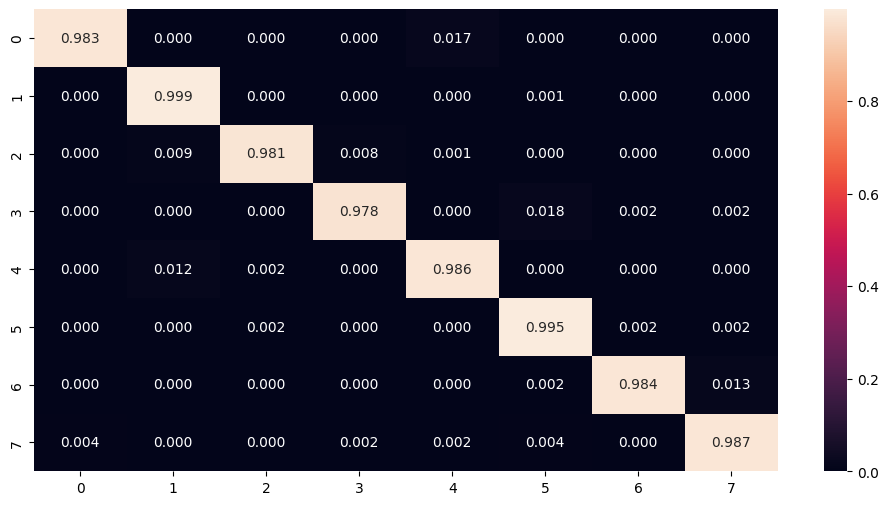

In [43]:
build_confusion_matrix(model_Conv_II, test_loader)

# Conclusion

In this notebook, we explored the impact of dataset balancing on model performance. 
The results showed that training on a balanced dataset led to improved performance, highlighting the importance of addressing class imbalances.

It is important to note that balancing techniques, such as oversampling and synthetic data generation, can be considered forms of data augmentation. By increasing the representation of underrepresented classes, we not only mitigate bias but also help the model generalize better. Understanding and applying these techniques effectively is essential for building robust machine learning models.